## SimpleRNN - Results Summary

- **Model:** SimpleRNN (two stacked layers)
- **Vocabulary size:** 50,000
- **Max sequence length:** 50
- **Embedding dim:** 128
- **Class weights:** balanced
- **Preprocessing:** lowercase, remove URLs, remove emojis

**Three architectures compared:**
- V1: hidden_size1=128, hidden_size2=64, Dropout(0.5)
- V2: hidden_size1=64,  hidden_size2=32, Dropout(0.5)
- V3: hidden_size1=64,  hidden_size2=32, no Dropout   ← selected

**Overall Test Results (V3 — selected):**
- Macro F1:  0.67
- Accuracy:  0.67

**Overall Test Results (V2):**
- Macro F1:  0.66
- Accuracy:  0.66

**Overall Test Results (V1):**
- Macro F1:  0.65
- Accuracy:  0.66

**Training Behaviour:**
- All three models peaked at epoch 2; early stopping correctly restored best weights
- V1 and V2: overfit from epoch 3 onward despite Dropout(0.5)
- V3: dropout removed — model converged cleaner and generalised better
- Key finding: Dropout(0.5) was too aggressive for the small 64→32 architecture,
  removing too much signal from an already low-capacity network

**Per-Language Results (V3 — selected):**
- Hausa  achieved a Macro F1 of 0.68 — marginal drop vs LogReg (0.71 → 0.68)
- Igbo   achieved a Macro F1 of 0.73 — matched LogReg (0.73 → 0.73)  ← best
- Pidgin achieved a Macro F1 of 0.39 — still the worst (Pidgin neutral F1: 0.04)
- Yoruba achieved a Macro F1 of 0.65 — slight drop vs LogReg (0.68 → 0.65)

**Key Findings:**
- V3 selected: removing dropout improved macro F1 (0.663 → 0.668) and positive
  F1 (0.68 → 0.72) — the small architecture needed its full capacity
- Igbo is the standout language — V3 matched LogReg exactly at 0.73, with
  positive F1 of 0.80 being the strongest single per-class result in this model
- Positive class has the highest precision across all languages (consistent with LogReg)
- Negative class is over-predicted across all languages — highest recall, lowest
  precision — most severe in Pidgin (recall 0.93, F1 0.74 but at cost of all else)
- Neutral class is the weakest point of V3 — dropped vs V2 (0.60 vs 0.67)
  as the model traded neutral recall for stronger negative and positive
- Pidgin neutral near-zero (F1: 0.04) — worse than LogReg's 0.13, confirms
  this is a data shortage problem (only 72 training samples), not a model problem
- Yoruba negative F1 of 0.57 remains the hardest per-class problem in the dataset —
  SimpleRNN struggles with Yoruba's tonal morphology and complex word structure
- SimpleRNN did not beat the LogReg baseline (0.67 vs 0.69)

**vs Logistic Regression Baseline:**
- Overall Macro F1:  0.67 vs 0.69  ← LogReg still leads
- Hausa  F1:  0.68 vs 0.71         ← LogReg leads
- Igbo   F1:  0.73 vs 0.73         ← tied
- Pidgin F1:  0.39 vs 0.44         ← LogReg leads
- Yoruba F1:  0.65 vs 0.68         ← LogReg leads
- Positive F1: 0.72 vs —           ← RNN edges LogReg on positive only

**This result motivates LSTM — gated memory should retain longer context,
reduce the negative over-prediction bias, and recover the neutral class
performance lost in V3 across all four languages.**

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# load the datasets
df_train = pd.read_csv('../01-data/02-processed/train_clean.csv')
df_test = pd.read_csv('../01-data/02-processed/test_clean.csv')
df_val = pd.read_csv('../01-data/02-processed/val_clean.csv')

In [3]:
def dataset_preprocessing(text):
    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
    )

    text = emoji_pattern.sub('', text)

    return text.strip()

In [4]:
# drop tweet length from train dataset
df_train.drop(columns=['tweet_length'], inplace=True)

df_list = [df_train, df_test, df_val]
for df in df_list:
    df['cleaned_tweet'] = df['tweet'].apply(dataset_preprocessing)
    df.drop(columns=['tweet'], inplace=True)
    df.rename(columns={'cleaned_tweet': 'tweet'}, inplace=True)

In [5]:
# split dataset for training, validation and testing
X_train = df_train['tweet']
y_train = df_train['label']
X_test = df_test['tweet']
y_test = df_test['label']
X_val = df_val['tweet']
y_val = df_val['label']

In [6]:
def preparation_for_model_train(X_train, X_val, X_test,
                                 y_train, y_val, y_test,
                                 vocab_size=50000, max_len=50):

    tokenizer = Tokenizer(num_words=vocab_size)

    tokenizer.fit_on_texts(X_train)

    # convert text to numbers

    X_train_seq = tokenizer.texts_to_sequences(X_train)

    X_val_seq = tokenizer.texts_to_sequences(X_val)

    X_test_seq = tokenizer.texts_to_sequences(X_test)

    # pad the sequences because RNN requires the same input size
    # we will choose 50 as the max length as prosposed during the eda process


    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)

    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)

    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

    label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}

    y_train = y_train.map(label_mapping).values

    y_val   = y_val.map(label_mapping).values

    y_test = y_test.map(label_mapping).values

    return X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test, tokenizer

In [7]:
X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test, tokenizer = preparation_for_model_train(
    X_train, X_val, X_test, y_train, y_val, y_test, vocab_size = 50000, max_len= 50
)

In [8]:
def build_simple_rnn_model(
        vocab_size=50000,
        embedding_dim=128,
        hidden_size1=128,
        hidden_size2=64,
        dropout_rate=0.5
):
    model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
        ),

    SimpleRNN(
        units=hidden_size1,
        return_sequences=True
        ),

    Dropout(dropout_rate),

    SimpleRNN(hidden_size2),
    
    Dropout(dropout_rate),

    Dense(3, activation="softmax")

    ])

    # compile the model
    model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

    return model

## Architecture Comparison

### Model V1 — 128 → 64 (medium data sizing)

In [9]:
model_rnn_v1 = build_simple_rnn_model()

In [ ]:
# compute and add class weights because of the limited 
# representation of the neutral sentiment for pidgin class
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(enumerate(weights))

# Early stopping is defined once and reused across all three model fits.
# This is intentional — EarlyStopping resets its internal state at the
# start of each model.fit() call, so there is no build early stopping again between models.
# patience=3 and restore_best_weights=True apply fresh to each run.

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=3,            # wait 3 epochs before stopping
    restore_best_weights=True  # roll back to best epoch weights
)

# Then in model.fit:
history = model_rnn_v1.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 75s 62ms/step - accuracy: 0.5407 - loss: 0.9372 - val_accuracy: 0.6822 - val_loss: 0.7265
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.7827 - loss: 0.5568 - val_accuracy: 0.7011 - val_loss: 0.7317
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.8995 - loss: 0.2834 - val_accuracy: 0.6771 - val_loss: 0.9032
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 87s 76ms/step - accuracy: 0.9494 - loss: 0.1485 - val_accuracy: 0.6709 - val_loss: 1.1461


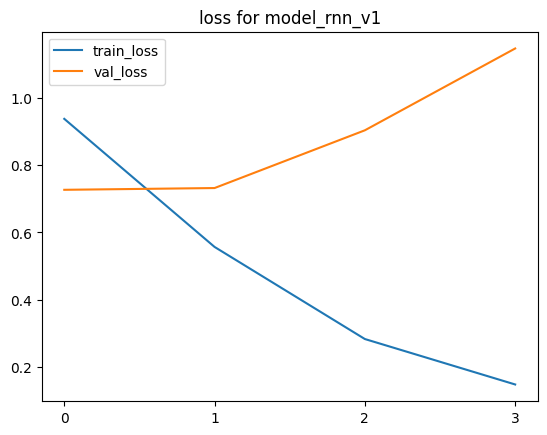

In [11]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for model_rnn_v1")
plt.legend()
plt.show()

In [12]:
predict = model_rnn_v1.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_v1: {f1}')
print("="*50)
print('CLASSIFICATION REPORT FOR model_rnn_v1')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


f1_macro_v1: 0.6542805430592008
CLASSIFICATION REPORT FOR model_rnn_v1
              precision    recall  f1-score   support

    negative       0.58      0.74      0.65      6009
     neutral       0.66      0.57      0.61      5457
    positive       0.75      0.65      0.70      6188

    accuracy                           0.66     17654
   macro avg       0.67      0.65      0.65     17654
weighted avg       0.67      0.66      0.66     17654



In [13]:
model_rnn_v2 = build_simple_rnn_model(hidden_size1=64, hidden_size2=32)

# Then in model.fit:
history = model_rnn_v2.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 59s 49ms/step - accuracy: 0.5664 - loss: 0.9054 - val_accuracy: 0.6844 - val_loss: 0.7518
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 60s 52ms/step - accuracy: 0.7908 - loss: 0.5414 - val_accuracy: 0.7068 - val_loss: 0.7336
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - accuracy: 0.8996 - loss: 0.2867 - val_accuracy: 0.6527 - val_loss: 0.9720


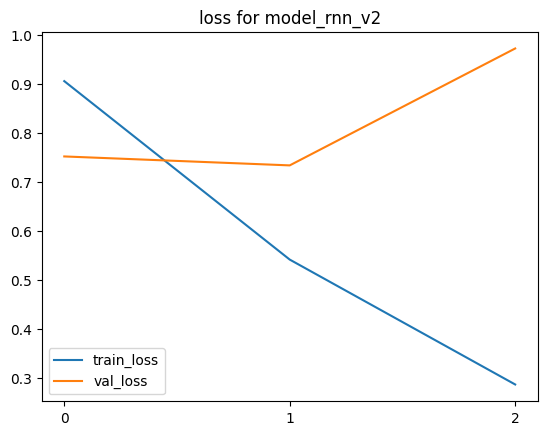

In [14]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for model_rnn_v2")
plt.legend()
plt.show()

In [15]:
predict = model_rnn_v2.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_v2: {f1}')
print("="*50)
print('CLASSIFICATION REPORT FOR model_rnn_v2')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


f1_macro_v2: 0.6625465530041362
CLASSIFICATION REPORT FOR model_rnn_v2
              precision    recall  f1-score   support

    negative       0.62      0.66      0.64      6009
     neutral       0.63      0.71      0.67      5457
    positive       0.76      0.62      0.68      6188

    accuracy                           0.66     17654
   macro avg       0.67      0.66      0.66     17654
weighted avg       0.67      0.66      0.66     17654



In [ ]:
def build_simple_rnn_model_v3(vocab_size=50000, embedding_dim=128,
                               hidden_size1=64, hidden_size2=32):
    # V3 differs from V1/V2 in two ways:
    # 1. No Dropout — removed because Dropout(0.5) was too aggressive
    #    for the small 64→32 architecture, hurting more than helping
    # 2. mask_zero=True in Embedding — tells the model to ignore
    #    padding tokens (0s) during training, which V1/V2 did not do
    
    model = Sequential([
        Embedding(vocab_size, embedding_dim, mask_zero=True),
        SimpleRNN(hidden_size1, return_sequences=True),
        SimpleRNN(hidden_size2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [18]:
model_rnn_v3 = build_simple_rnn_model_v3()

# Then in model.fit:
history = model_rnn_v3.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 70s 58ms/step - accuracy: 0.6518 - loss: 0.7774 - val_accuracy: 0.7030 - val_loss: 0.6869
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.8721 - loss: 0.3430 - val_accuracy: 0.7097 - val_loss: 0.7965
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - accuracy: 0.9661 - loss: 0.1012 - val_accuracy: 0.6988 - val_loss: 1.0698
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 73s 64ms/step - accuracy: 0.9852 - loss: 0.0453 - val_accuracy: 0.6759 - val_loss: 1.4468


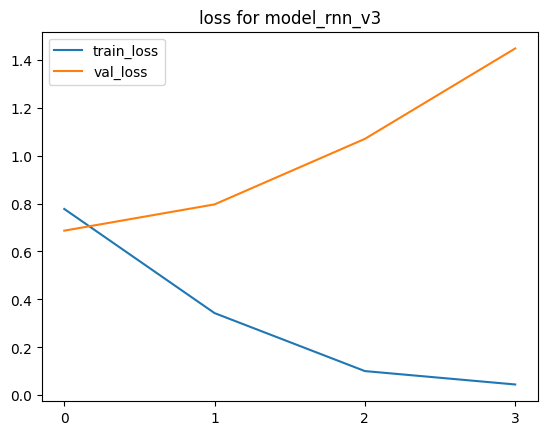

In [24]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.title("loss for model_rnn_v3")
plt.legend()
plt.show()

In [22]:
predict = model_rnn_v3.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print()
print()
print(f'f1_macro_v3: {f1}')
print("="*50)
print('CLASSIFICATION REPORT FOR model_rnn_v3')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


f1_macro_v3: 0.6676619328925243
CLASSIFICATION REPORT FOR model_rnn_v3
              precision    recall  f1-score   support

    negative       0.58      0.84      0.68      6009
     neutral       0.73      0.51      0.60      5457
    positive       0.79      0.66      0.72      6188

    accuracy                           0.67     17654
   macro avg       0.70      0.67      0.67     17654
weighted avg       0.70      0.67      0.67     17654



In [23]:
reverse_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
predict = model_rnn_v3.predict(X_test_pad)
y_pred = np.argmax(predict, axis=1)
df_test['predicted'] = y_pred
df_test['predicted'] = df_test['predicted'].map(reverse_mapping)

for lang in ['hausa', 'igbo', 'pidgin', 'yoruba']:
    subset = df_test[df_test['language'] == lang]
    print(f"\n{'='*50}")
    print(f"Language: {lang.upper()}")
    print(f"{'='*50}")
    print(classification_report(subset['label'], subset['predicted'],
                                target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step

Language: HAUSA
              precision    recall  f1-score   support

    negative       0.59      0.82      0.68      1759
     neutral       0.71      0.45      0.55      1789
    positive       0.83      0.80      0.82      1755

    accuracy                           0.69      5303
   macro avg       0.71      0.69      0.68      5303
weighted avg       0.71      0.69      0.68      5303


Language: IGBO
              precision    recall  f1-score   support

    negative       0.61      0.77      0.68       943
     neutral       0.77      0.67      0.71      1621
    positive       0.81      0.79      0.80      1118

    accuracy                           0.73      3682
   macro avg       0.73      0.74      0.73      3682
weighted avg       0.74      0.73      0.73      3682


Language: PIDGIN
              precision    recall  f1-score   support

    negative       0.61      0.93      0.74      2326
     neutral       0.29      0.02   